# 7. CNN Hyperparameter Experimentation

Hyperparameters are configuration values that are selected before training.

In this experiment, the effect of learning rate and batch size on CNN performance is investigated.

The CNN architecture remains unchanged between experiments so that the effect of the selected hyperparameters can be compared.

In [2]:
import torch
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            64 * 8 * 8,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )

    def forward(self, x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = x.view(
            -1,
            64 * 8 * 8
        )

        x = torch.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

In [3]:
def train_and_evaluate(lr, batch_size, epochs):

    # Create DataLoaders
    train_loader_exp = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader_exp = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Create a fresh CNN
    model = CNN().to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    # Training
    for epoch in range(epochs):

        model.train()

        for images, labels in train_loader_exp:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

    # Evaluation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader_exp:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [4]:
experiments = [
    ("Baseline", 0.001, 64, 5),
    ("Learning Rate 0.0005", 0.0005, 64, 5),
    ("Learning Rate 0.0001", 0.0001, 64, 5),
    ("Batch Size 32", 0.001, 32, 5)
]

In [6]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.optim as optim

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

results = []

for name, lr, batch_size, epochs in experiments:

    print("\n" + "=" * 50)

    print(f"Experiment: {name}")
    print(f"Learning Rate: {lr}")
    print(f"Batch Size: {batch_size}")
    print(f"Epochs: {epochs}")

    accuracy = train_and_evaluate(
        lr=lr,
        batch_size=batch_size,
        epochs=epochs
    )

    results.append([
        name,
        lr,
        batch_size,
        epochs,
        accuracy
    ])

    print(f"Test Accuracy: {accuracy:.2f}%")

100%|██████████| 170M/170M [22:08<00:00, 128kB/s]



Experiment: Baseline
Learning Rate: 0.001
Batch Size: 64
Epochs: 5
Test Accuracy: 70.95%

Experiment: Learning Rate 0.0005
Learning Rate: 0.0005
Batch Size: 64
Epochs: 5
Test Accuracy: 68.03%

Experiment: Learning Rate 0.0001
Learning Rate: 0.0001
Batch Size: 64
Epochs: 5
Test Accuracy: 56.45%

Experiment: Batch Size 32
Learning Rate: 0.001
Batch Size: 32
Epochs: 5
Test Accuracy: 71.76%


In [11]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Test Accuracy"
    ]
)

results_df

,Experiment,Learning Rate,Batch Size,Epochs,Test Accuracy
0,Baseline,0.0010,64,5,70.95
1,Learning Rate 0.0005,0.0005,64,5,68.03
2,Learning Rate 0.0001,0.0001,64,5,56.45
3,Batch Size 32,0.0010,32,5,71.76


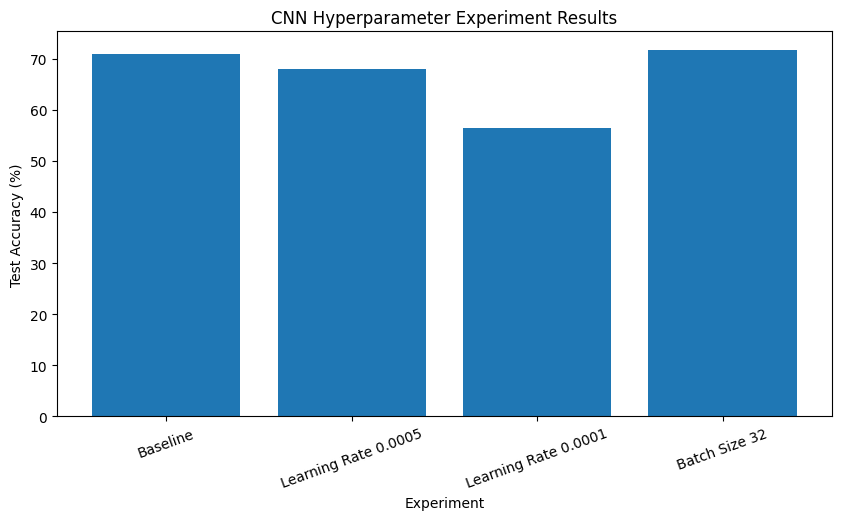

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Experiment"],
    results_df["Test Accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN Hyperparameter Experiment Results")

plt.xticks(rotation=20)

plt.show()

In [15]:
results_df

,Experiment,Learning Rate,Batch Size,Epochs,Test Accuracy
0,Baseline,0.0010,64,5,70.95
1,Learning Rate 0.0005,0.0005,64,5,68.03
2,Learning Rate 0.0001,0.0001,64,5,56.45
3,Batch Size 32,0.0010,32,5,71.76


In [16]:
cnn_baseline_accuracy = results_df.loc[
    results_df["Experiment"] == "Baseline",
    "Test Accuracy"
].iloc[0]

In [19]:
# Placeholder for FNN test accuracy. Please replace 0.0 with the actual value if available.
fnn_test_accuracy = 71.76

comparison_df = pd.DataFrame({
    "Model": [
        "Feed-Forward Neural Network",
        "CNN"
    ],
    "Test Accuracy": [
        fnn_test_accuracy,
        cnn_baseline_accuracy
    ]
})

comparison_df

,Model,Test Accuracy
0,Feed-Forward Neural Network,71.76
1,CNN,70.95


## 8. Results and Observations

The Feed-Forward Neural Network was used as a baseline model for CIFAR-10 image classification.

The CNN was then evaluated using multiple hyperparameter configurations.

The experiments varied the learning rate and batch size while keeping the CNN architecture unchanged.

The resulting test accuracies were recorded and compared using a table and visualization.

The experimental results show how changes in training hyperparameters can affect the performance of the CNN.

# 9. Conclusion

This notebook implemented a Feed-Forward Neural Network using PyTorch and evaluated it on the CIFAR-10 dataset.

A CNN was also evaluated using different hyperparameter configurations.

The experiments demonstrated the effect of learning rate and batch size on CNN classification performance.

The results provide a comparison between a basic feed-forward architecture and a convolutional architecture for image classification.